In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from gammapy.datasets import Datasets, FluxPointsDataset
from gammapy.estimators import FluxPoints
from gammapy.modeling import Fit
from gammapy.modeling.models import SkyModel, Models
from pathlib import Path
from astropy.table import Table
import sys
import astropy.constants as const

ROOT = Path("/Users/ruby/Desktop/University/phd/bhjet_mod/modBHJet")
sys.path.insert(0, str(ROOT / "python"))

from bhjet import BHJet, BLJet
from bhjet.gammapy import BHJetSpectralModel

In [2]:
def load_isis_xray_fluxpoints(filename):
    """
    Load ISIS fancy_plot_unit("hz", "ergs") output.

    Expected columns
    ----------------
    nu_min, nu_max, nufnu, nufnu_err_lo, nufnu_err_hi

    Returns
    -------
    flux_points : gammapy.estimators.FluxPoints
        Flux points represented as dN/dE in cm^-2 s^-1 eV^-1.
    table : astropy.table.Table
        Converted input table.
    """
    data = np.loadtxt(filename)

    if data.ndim == 1:
        data = data[None, :]

    if data.shape[1] != 5:
        raise ValueError(
            f"Expected 5 columns, found {data.shape[1]}."
        )

    nu_min = data[:, 0] * u.Hz
    nu_max = data[:, 1] * u.Hz

    nufnu = data[:, 2] * u.Unit("erg cm-2 s-1")
    nufnu_err_lo = data[:, 3] * u.Unit("erg cm-2 s-1")
    nufnu_err_hi = data[:, 4] * u.Unit("erg cm-2 s-1")

    # Geometric centre, appropriate for logarithmic spectral bins.
    nu_ref = np.sqrt(nu_min * nu_max)

    e_min = nu_min.to(u.eV, equivalencies=u.spectral())
    e_ref = nu_ref.to(u.eV, equivalencies=u.spectral())
    e_max = nu_max.to(u.eV, equivalencies=u.spectral())

    # ISIS "ergs" quantity is assumed to be nu F_nu = E^2 dN/dE.
    # Use energy in erg first so Astropy handles the differential unit
    # conversion correctly.
    e_ref_erg = e_ref.to(u.erg)

    dnde = (
        nufnu / e_ref_erg**2
    ).to("cm-2 s-1 eV-1")

    dnde_err_lo = (
        nufnu_err_lo / e_ref_erg**2
    ).to("cm-2 s-1 eV-1")

    dnde_err_hi = (
        nufnu_err_hi / e_ref_erg**2
    ).to("cm-2 s-1 eV-1")

    # Temporary symmetric error for simple loading/testing.
    dnde_err = 0.5 * (dnde_err_lo + dnde_err_hi)

    table = Table()
    table["e_min"] = e_min
    table["e_ref"] = e_ref
    table["e_max"] = e_max
    table["dnde"] = dnde
    table["dnde_err"] = dnde_err

    table.sort("e_ref")
    flux_points = FluxPoints.from_table(
        table,
        sed_type="dnde",
    )

    np.savetxt(
    "data/ngc4261_xray_converted.txt",
    np.column_stack([
        table["e_min"].value,
        table["e_ref"].value,
        table["e_max"].value,
        table["dnde"].value,
        table["dnde_err"].value,
    ]),
    header="e_min[eV] e_ref[eV] e_max[eV] dnde dnde_err",
    )
    
    return flux_points, table

In [3]:
#formatting the data 
H_EV_S = 4.135667696e-15       # eV s
H_ERG_S = 6.62607015e-27       # erg s
MJY_TO_CGS = 1e-26             # erg cm^-2 s^-1 Hz^-1

def hz_to_ev(hz): 
    eV = np.asarray(hz) * H_EV_S
    return eV

def mjy_to_number_flux(freq_hz,flux): #convert from mjy to dnde
    eV = hz_to_ev(freq_hz)
    flux_nu = flux * MJY_TO_CGS 
    dnde = flux_nu / (H_ERG_S*eV)
    return dnde

# data = np.loadtxt("data/ngc4261_mjy.txt")
# freq = data[:,0]
# flux = data[:,1]
# err = data[:,2]

# energy_eV = hz_to_ev(freq)
# dnde = mjy_to_number_flux(freq,flux)
# dnde_err = mjy_to_number_flux(freq,err)
# data_dnde = np.column_stack((energy_eV, dnde, dnde_err))
# np.savetxt("data/ngc4261_dnde.csv", data_dnde,  header="e_ref dnde dnde_err")

file = "data/ngc4261/ngc4261_dnde.csv" #make sure to check that the # comment is gone
data_table = Table.read(file, format="ascii.csv", delimiter=' ')
data_table.sort(keys="e_ref")
data_table["e_ref"].unit = u.eV
data_table["dnde"].unit = u.Unit("cm-2s-1eV-1")
data_table["dnde_err"].unit = u.Unit("cm-2s-1eV-1")

Using fluxpoints container in gammapy: the following formats and minimum required columns are:
- Format dnde: columns e_ref and dnde 
- Format e2dnde: columns e_ref, e2dnde
- Format flux: columns e_min, e_max, flux
- Format eflux: columns e_min, e_max, eflux

Manually/By Hand Loading & Converting

In [4]:
data_flux_points = FluxPoints.from_table(data_table,sed_type="dnde")
#these also return fluxpoints from table 
xray_flux_points, xray_table = load_isis_xray_fluxpoints("data/ngc4261/ngc4261_xray.txt")
gammaray_flux_points, gammaray_table = load_isis_xray_fluxpoints("data/ngc4261/ngc4261_gamma_ray.txt")

### now have to also turn them into flux point datasets? 
radio_dataset = FluxPointsDataset(data=data_flux_points,name="radio_ir_uv")
xray_dataset = FluxPointsDataset(data=xray_flux_points,name="xray")
gamma_dataset = FluxPointsDataset(data=gammaray_flux_points,name="gamma_ray")

# help(txs_flux.plot)

No reference model set for FluxMaps. Assuming point source with E^-2 spectrum.
No reference model set for FluxMaps. Assuming point source with E^-2 spectrum.
No reference model set for FluxMaps. Assuming point source with E^-2 spectrum.


/Users/ruby/anaconda3/envs/gammapy-2.1/lib/python3.12/site-packages/gammapy/maps/region/ndmap.py:154: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.errorbar(


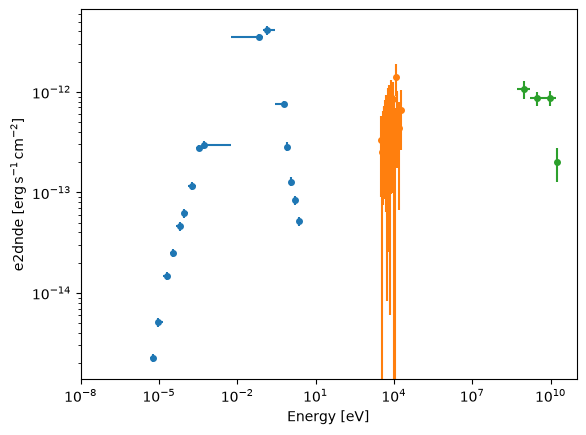

In [5]:
data_flux_points.plot(sed_type="e2dnde")
xray_flux_points.plot(sed_type='e2dnde')
gammaray_flux_points.plot(sed_type='e2dnde')

# plt.xlim(1e-8, 1e13)
# plt.ylim(1e-14, 1e-10)
plt.xlim(1e-8, 1e11)
plt.show()

In [6]:
# # Setting up all the model definitions (for the first time:)
# bhjet_test = BHJetSpectralModel()
# bhjet_model_test = SkyModel(spectral_model= bhjet_test, name = 'bhjet')
# models = Models([bhjet_model_test])
# models.write("data/ngc4261/ngc4261_test.yaml", overwrite=True)

#Then if a model needs to be loaded: 
bhjet_model = Models.read("data/ngc4261/ngc4261_test.yaml")
bhjet_spec = bhjet_model['bhjet'].spectral_model #this is for plotting/using the plot through gammapy 

#putting datasets together & assign to model: 
datasets = Datasets([radio_dataset, xray_dataset, gamma_dataset])
datasets.models = bhjet_model

# models.parameters.to_table()

In [7]:
#this is for txs 0506
# models = Models.read("data/txs0506/txs_0506_test.yaml") #load the model 
# data_flux.models=models #assign data to the model 
# bhjet_gp = models['bhjet'].spectral_model #I think this is how I should call the spectral model again to plot it 
# # models.to_parameters_table()

In [18]:
bhjet_spec.index_injected_electrons.value = 1.85
bhjet_spec.factor_max_energy_electrons.value = 4e-8
bhjet_spec.jet_power_eddington.value = 0.003
bhjet_spec.electron_temperature_jet_base.value = 500
bhjet_spec.jet_power_eddington.value = 0.0032

/Users/ruby/anaconda3/envs/gammapy-2.1/lib/python3.12/site-packages/gammapy/maps/region/ndmap.py:154: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.errorbar(


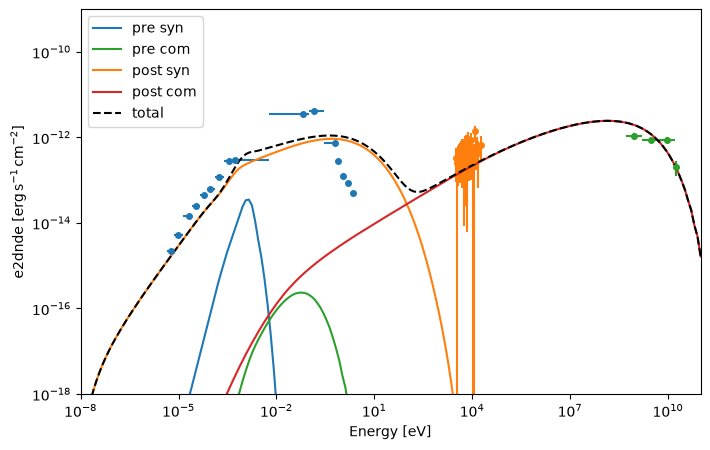

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

data_flux_points.plot(ax=ax, sed_type="e2dnde")
xray_flux_points.plot(ax=ax, sed_type="e2dnde")
gammaray_flux_points.plot(ax=ax, sed_type="e2dnde")

bhjet_spec.plot_components(energy_bounds=[1e-8, 1e11] * u.eV,ax=ax,energy_power=2)

ax.set_xlim(1e-8, 1e11)
ax.set_ylim(1e-18, 1e-9)
ax.legend()
plt.show()

In [12]:
fitter = Fit(backend='minuit')
results = fitter.run(datasets=datasets)

In [13]:
print(results)
print(bhjet_model.parameters.free_parameters.to_table())

OptimizeResult

	backend    : minuit
	method     : migrad
	success    : False
	message    : Optimization failed. Call limit was reached.
	nfev       : 1344
	total stat : 534.79

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.

type              name               value    unit ... frozen link prior
---- ----------------------------- ---------- ---- ... ------ ---- -----
               jet_power_eddington 4.6523e-03      ...  False           
                         r_initial 1.3081e+01      ...  False           
             z_end_of_acceleration 1.6493e+02      ...  False           
                     z_dissipation 1.0151e+02      ...  False           
                       sigma_final 3.0762e-04      ...  False           
     electron_temperature_jet_base 4.0002e+02      ...  False           
       factor_max_energy_electrons 1.0129e-09      ...  False           
          index_injected_electrons 1.6862